In [1]:
%matplotlib widget

# Machine learning

In [2]:
# Import libraries

import numpy as np
import matplotlib.pyplot as plt
import empymod 
from scipy.constants import mu_0
import pygimli as pg
from pygimli.viewer.mpl import drawModel1D
from sklearn.metrics import root_mean_squared_error
from numpy import linalg as LA
from itertools import product
import plotly.express as px
import pandas as pd
from mpl_toolkits.mplot3d import axes3d
import matplotlib.colors as colors
import random
import itertools

from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [3]:
# Load models and data

models = np.load('Models/models_UR.npy')
data = np.load('Data/data_UR.npy')

Data = pd.DataFrame(np.hstack((models, data)), columns = ['h1', 'logs1', 'logs2', 'h2op', 'h4op', 'h8op', 'h2ip', 'h4ip', 'h8ip', 'v2op', 'v4op',
                                      'v8op', 'v2ip', 'v4ip', 'v8ip', 'p2op', 'p4op', 'p8op', 'p2ip', 'p4ip', 'p8ip'])

In [4]:
Data

,h1,logs1,logs2,h2op,h4op,h8op,h2ip,h4ip,h8ip,v2op,...,v8op,v2ip,v4ip,v8ip,p2op,p4op,p8op,p2ip,p4ip,p8ip
0,0.1,-3.000000,-2.938776,-0.079278,-0.312817,-1.200310,-0.001640,-0.012916,-0.100084,-0.107776,...,-1.294052,-0.002220,-0.017381,-0.134373,0.070675,0.304598,1.261926,0.000033,0.000451,0.006032
1,0.1,-3.000000,-2.877551,-0.091256,-0.359200,-1.373331,-0.002024,-0.015922,-0.123079,-0.121700,...,-1.466330,-0.002733,-0.021406,-0.165163,0.082442,0.352881,1.457206,0.000043,0.000588,0.007836
2,0.1,-3.000000,-2.816327,-0.105014,-0.412341,-1.570441,-0.002497,-0.019625,-0.151300,-0.137602,...,-1.661782,-0.003367,-0.026364,-0.202951,0.095990,0.408469,1.681976,0.000056,0.000766,0.010176
3,0.1,-3.000000,-2.755102,-0.120814,-0.473201,-1.794792,-0.003082,-0.024183,-0.185915,-0.155781,...,-1.883267,-0.004149,-0.032469,-0.249303,0.111589,0.472466,1.940673,0.000073,0.000998,0.013209
4,0.1,-3.000000,-2.693878,-0.138956,-0.542870,-2.049902,-0.003802,-0.029793,-0.228349,-0.176578,...,-2.133927,-0.005114,-0.039985,-0.306126,0.129549,0.546144,2.238404,0.000095,0.001300,0.017138
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61245,6.0,-0.183673,-0.061224,-24.751816,-30.888526,175.426378,-14.062395,-69.893977,-143.482814,-34.511757,...,444.200288,-20.531647,-100.697788,-189.041309,38.004938,148.274221,416.821781,3.774796,37.883727,280.861017
61246,6.0,-0.183673,0.000000,-24.821260,-31.441832,171.923796,-13.965693,-69.310352,-142.631784,-34.543427,...,442.211623,-20.476652,-100.310331,-187.177521,37.998122,148.146041,414.422144,3.803850,38.281647,284.274068
61247,6.0,-0.122449,-0.061224,-26.808751,-25.491886,225.754182,-16.907099,-80.480775,-132.850713,-37.402367,...,542.247027,-24.670822,-115.712648,-169.354122,43.489232,167.152727,446.589651,4.760856,46.630251,329.355279
61248,6.0,-0.122449,0.000000,-26.882827,-26.063457,222.468226,-16.826256,-80.013101,-132.585232,-37.437001,...,540.222000,-24.623286,-115.382900,-167.879775,43.479962,166.992112,443.976386,4.787287,46.987339,332.222457


In [5]:
Data = Data.sample(10000, random_state=42)

# Analize available data

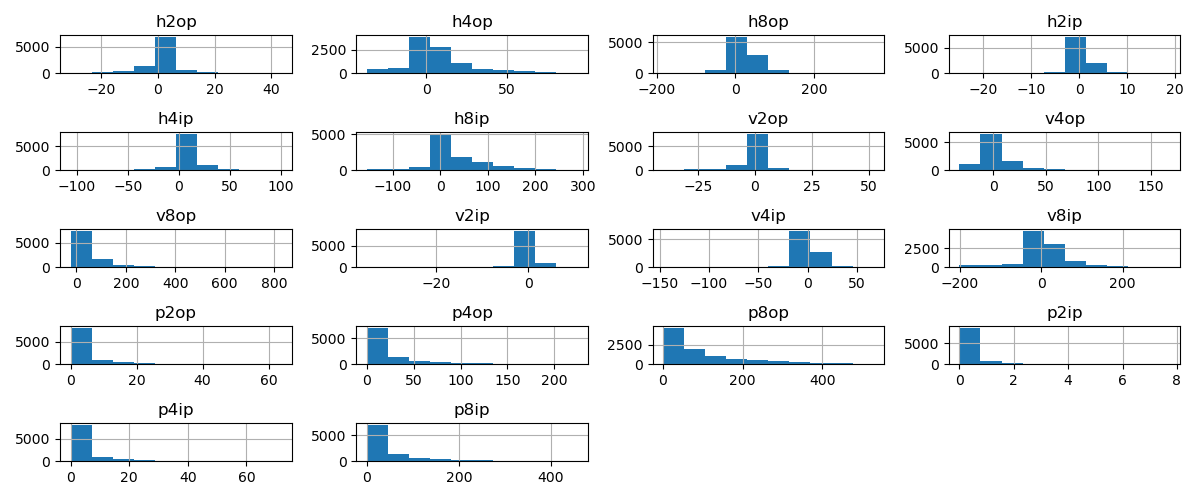

In [6]:
# Scale data and models

ydata = Data[['h2op', 'h4op', 'h8op', 'h2ip', 'h4ip', 'h8ip', 'v2op', 'v4op',
               'v8op', 'v2ip', 'v4ip', 'v8ip', 'p2op', 'p4op', 'p8op', 'p2ip', 'p4ip', 'p8ip']]
ydata.hist(figsize=(12,5))
plt.tight_layout()
plt.show()

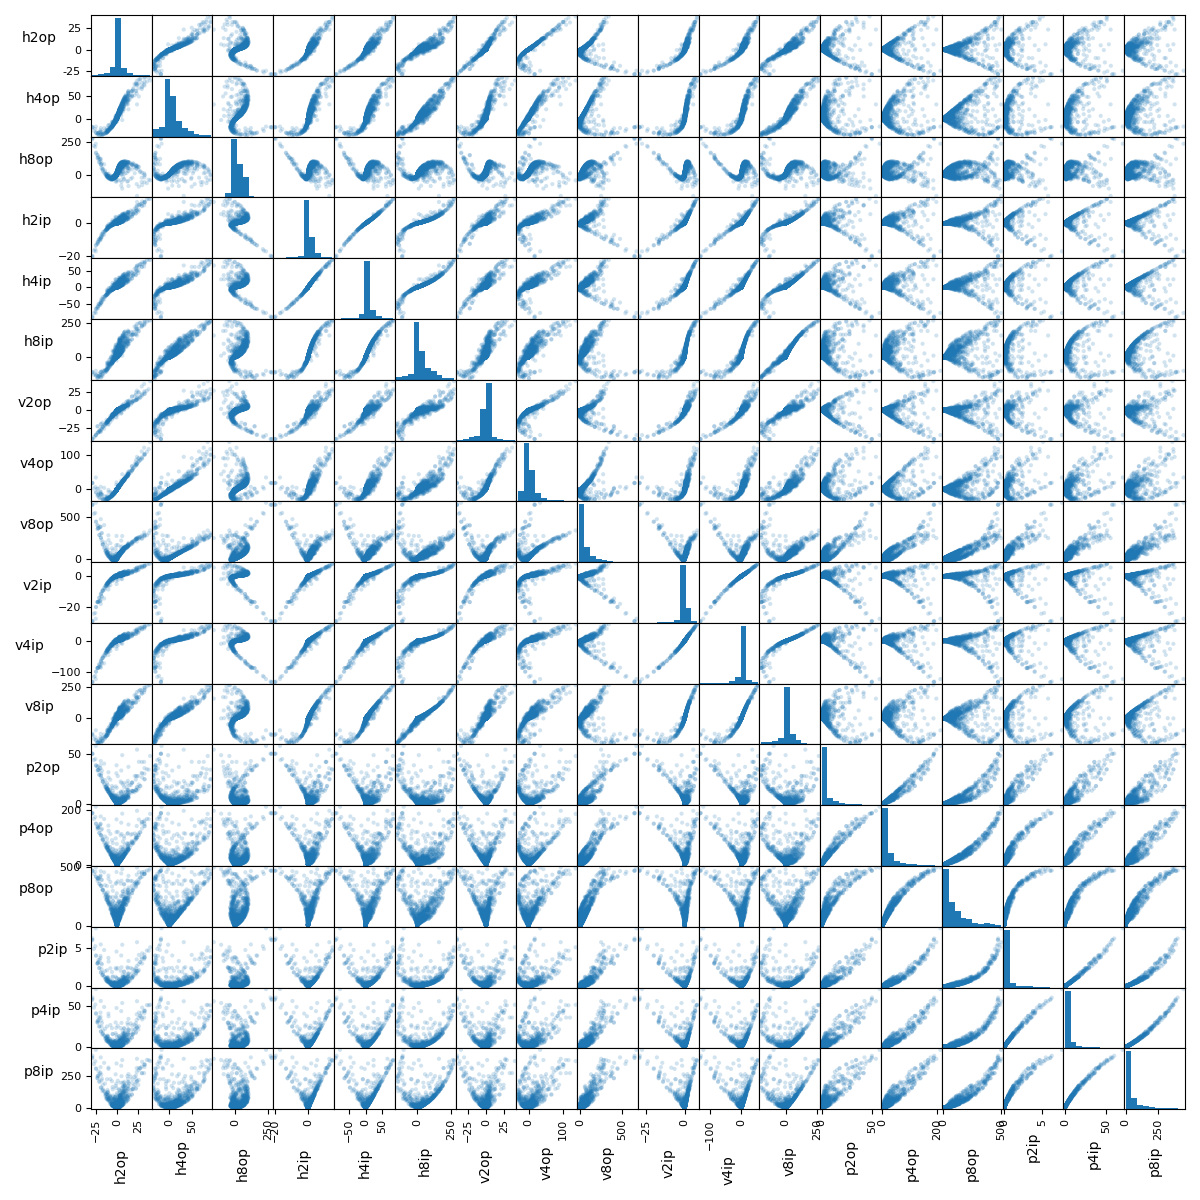

In [7]:
 # Check possible correlations
datasamp = ydata.sample(1000)

axes = pd.plotting.scatter_matrix(datasamp, alpha=0.2, figsize =(12,12))
# need to rotate axis labels so we can read them
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')
plt.tight_layout()
plt.gcf().subplots_adjust(wspace=0, hspace=0)
plt.show()

Text(0.5, 1.0, 'Correlation to h1')

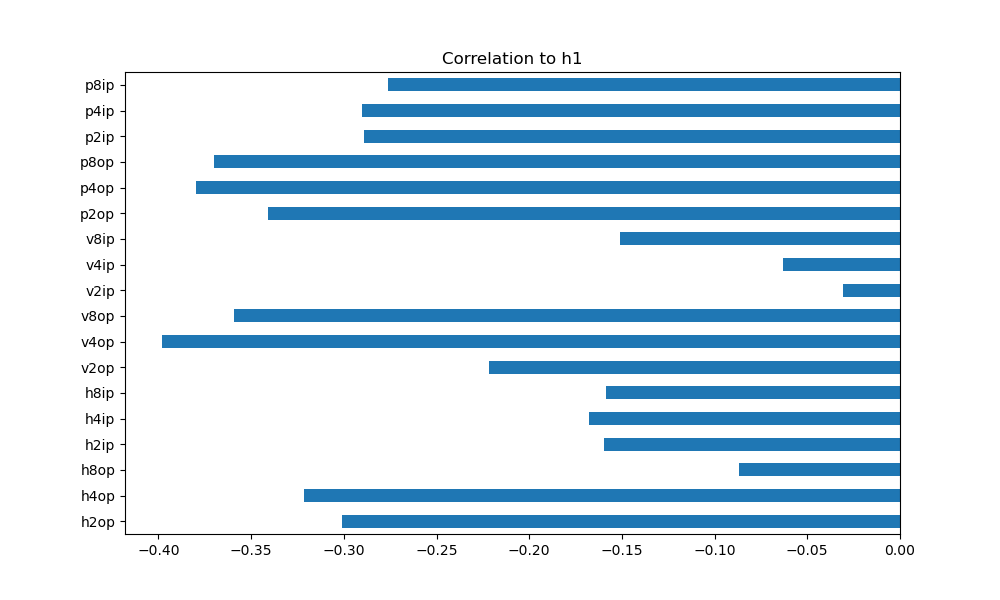

In [8]:
plt.figure()
correlation_values_h1 = Data.corr()['h1'].drop(['h1', 'logs1', 'logs2'])
correlation_values_h1.plot(kind='barh', figsize=(10, 6))
plt.title('Correlation to h1')

Text(0.5, 1.0, 'Correlation to s1')

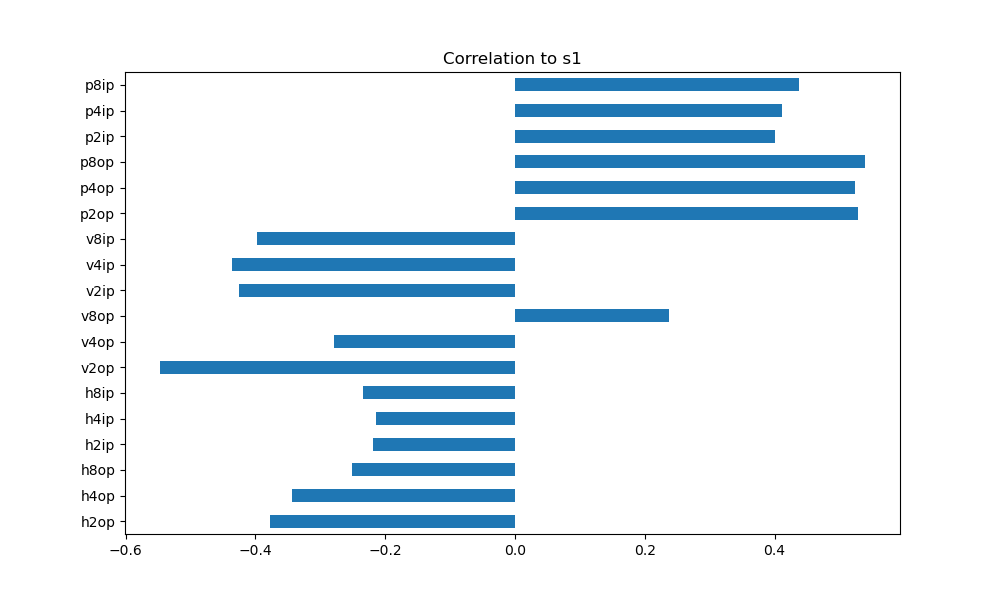

In [9]:
plt.figure()
correlation_values_h1 = Data.corr()['logs1'].drop(['h1', 'logs1', 'logs2'])
correlation_values_h1.plot(kind='barh', figsize=(10, 6))
plt.title('Correlation to s1')

Text(0.5, 1.0, 'Correlation to s2')

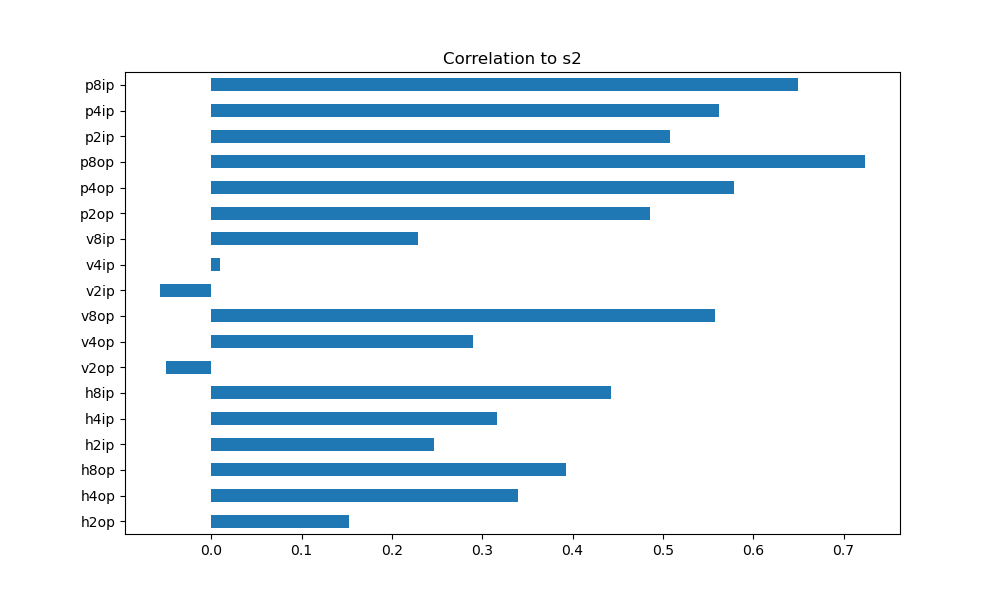

In [10]:
plt.figure()
correlation_values_h1 = Data.corr()['logs2'].drop(['h1', 'logs1', 'logs2'])
correlation_values_h1.plot(kind='barh', figsize=(10, 6))
plt.title('Correlation to s2')

<Axes: >

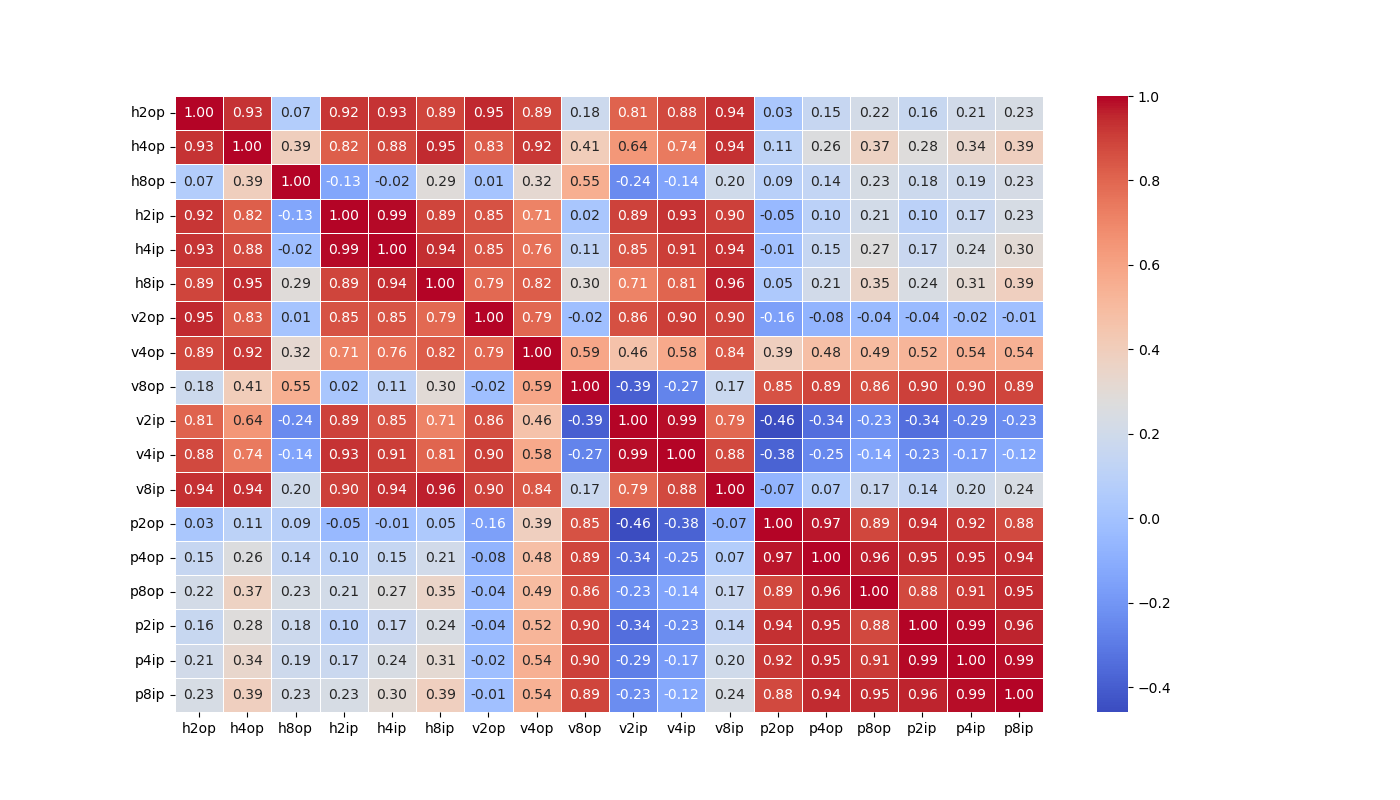

In [11]:

plt.figure(figsize=(14, 8))
correlation_matrix = ydata.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

# Standarize dataset

In [12]:
scale_x = StandardScaler()
scale_y = StandardScaler()

Data_X = Data.drop(['h1', 'logs1', 'logs2'], axis=1)
Data_y = Data.drop(['h2op', 'h4op', 'h8op', 'h2ip', 'h4ip', 'h8ip', 'v2op', 'v4op',
                    'v8op', 'v2ip', 'v4ip', 'v8ip', 'p2op', 'p4op', 'p8op', 'p2ip', 'p4ip', 'p8ip'], axis=1)

X = scale_x.fit_transform(Data_X)
y = scale_y.fit_transform(Data_y)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)

## Add noise to y_train

In [14]:
noise_std = 0.05
rng = np.random.RandomState(1)
y_train_noisy = y_train + rng.normal(loc=0.0, scale=noise_std, size=y_train.shape)
X_train_noisy = X_train + rng.normal(loc=0.0, scale=noise_std, size=X_train.shape)

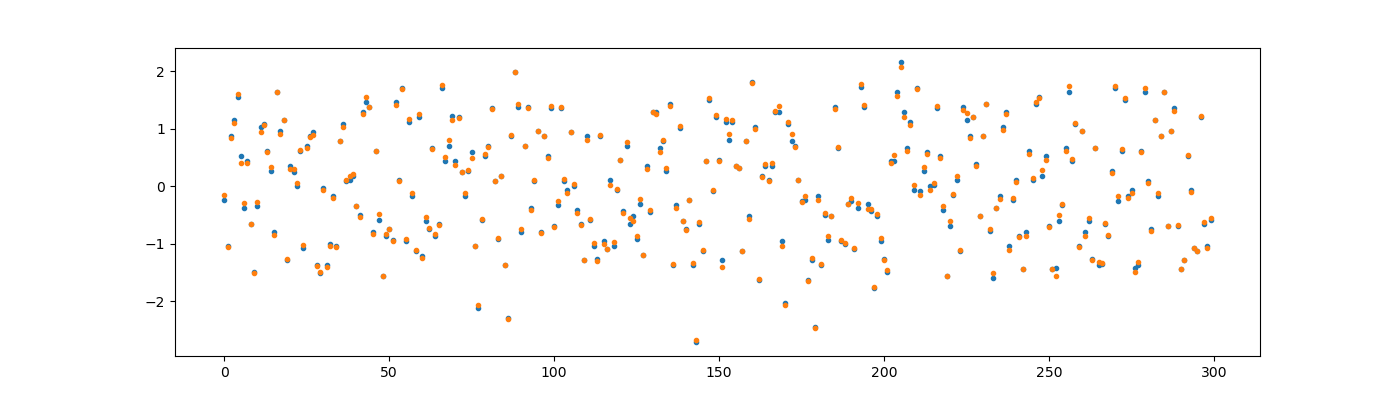

In [15]:
plt.figure(figsize = (14,4))
plt.plot(y_train[:100].ravel(), '.')
plt.plot(y_train_noisy[:100].ravel(), '.')

# Grid search of MLP Regressor

In [16]:
# Define the model
mlp = MLPRegressor(max_iter=2000, early_stopping=True, random_state=42)

# Define the parameter grid
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50), (50, 50, 50)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'sgd'],
    'learning_rate': ['constant', 'adaptive'],
    'alpha': [0.0001, 0.001, 0.01],  # L2 regularization term
}

# Set up the grid search
grid_search = GridSearchCV(mlp, param_grid, cv=5, scoring='r2', n_jobs=20, verbose=1)

# Fit the model
grid_search.fit(X_train_noisy, y_train_noisy)

# Best parameters
# Best parameters
print("Best parameters:", grid_search.best_params_)
print("Best R² score:", grid_search.best_score_)

Fitting 5 folds for each of 120 candidates, totalling 600 fits
Best parameters: {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (50, 50, 50), 'learning_rate': 'constant', 'solver': 'adam'}
Best R² score: 0.8792058231168433


In [17]:
# Enter your code here
test_score = grid_search.score(X_test, y_test)
print(f"{test_score:.3f}")

0.913


In [18]:
# Make predictions on the entire test set
y_pred = grid_search.predict(X_test)

# Compute metrics for each output variable separately
for i in range(y_test.shape[1]):  # Loop through each target variable
    r2 = r2_score(y_test[:, i], y_pred[:, i])
    mae = mean_absolute_error(y_test[:, i], y_pred[:, i])
    mse = mean_squared_error(y_test[:, i], y_pred[:, i])
    
    print(f"Output variable {i+1}:")
    print(f"  R² Score: {r2:.4f}")
    print(f"  Mean Absolute Error (MAE): {mae:.4f}")
    print(f"  Mean Squared Error (MSE): {mse:.4f}\n")

Output variable 1:
  R² Score: 0.7818
  Mean Absolute Error (MAE): 0.2778
  Mean Squared Error (MSE): 0.2178

Output variable 2:
  R² Score: 0.9689
  Mean Absolute Error (MAE): 0.1152
  Mean Squared Error (MSE): 0.0316

Output variable 3:
  R² Score: 0.9872
  Mean Absolute Error (MAE): 0.0669
  Mean Squared Error (MSE): 0.0128



In [19]:
n = 50

# Define a single test sample (ensure it's 2D: shape (1, n_features))
X_test_single = X_test[n].reshape(1, -1)  # Pick the first test sample

# Make prediction
y_pred_single = grid_search.predict(X_test_single)

# Print the predicted value
print("Predicted output for the single test sample:", scale_y.inverse_transform(y_pred_single))
print('True output for the test sample             ', scale_y.inverse_transform(y_test[n].reshape(1, -1)))
mse = mean_squared_error(y_test[n], y_pred_single[0])
print('mean squared error:', mse)

Predicted output for the single test sample: [[ 5.47043123 -1.02677557 -0.5945152 ]]
True output for the test sample              [[ 5.87959184 -1.04081633 -0.55102041]]
mean squared error: 0.019858624382362338


Text(0.5, 1.0, 'log s2 - r2: 0.9872')

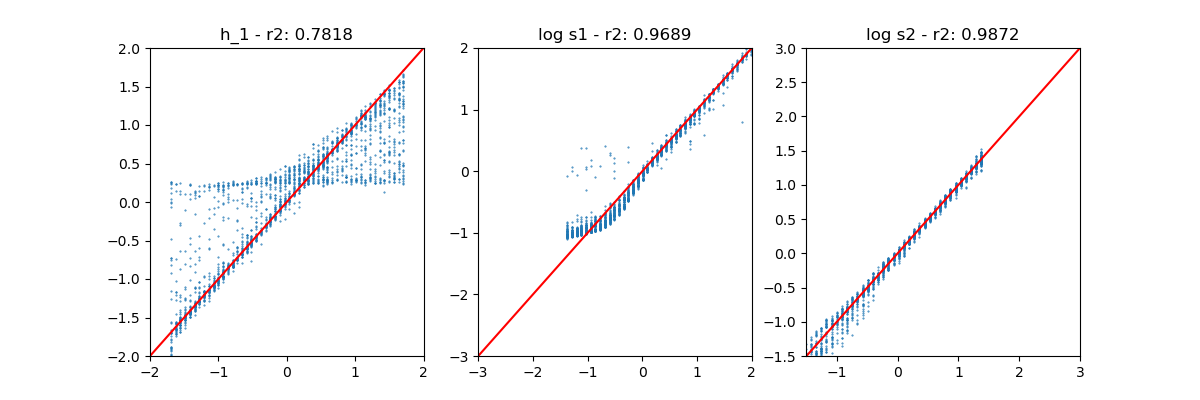

In [20]:
fig, ax = plt.subplots(1,3, figsize=(12,4))

ax[0].scatter(y_test[:,0], y_pred[:,0], s=0.2)
r2_h1 = r2_score(y_test[:, 0], y_pred[:, 0])
ax[0].plot([-2, 2], [-2, 2], 'r')
ax[1].scatter(y_test[:,1], y_pred[:,1], s=0.2)
r2_s1 = r2_score(y_test[:, 1], y_pred[:, 1])
ax[1].plot([-3,2], [-3,2], 'r')
ax[2].scatter(y_test[:,2], y_pred[:,2], s=0.2)
r2_s2 = r2_score(y_test[:, 2], y_pred[:, 2])
ax[2].plot([-1.5, 3], [-1.5, 3], 'r')

ax[0].set_xlim([-2, 2])
ax[0].set_ylim([-2, 2])

ax[1].set_xlim([-3, 2])
ax[1].set_ylim([-3, 2])

ax[2].set_xlim([-1.5, 3])
ax[2].set_ylim([-1.5, 3])

ax[0].set_title(f'h_1 - r2: {r2_h1:.4f}')
ax[1].set_title(f'log s1 - r2: {r2_s1:.4f}')
ax[2].set_title(f'log s2 - r2: {r2_s2:.4f}')

# Reduce variables in X

In [22]:
models = np.load('Models/models_UR.npy')
data = np.load('Data/data_UR.npy')

Data = pd.DataFrame(np.hstack((models, data)), columns = ['h1', 'logs1', 'logs2', 'h2op', 'h4op', 'h8op', 'h2ip', 'h4ip', 'h8ip', 'v2op', 'v4op',
                                      'v8op', 'v2ip', 'v4ip', 'v8ip', 'p2op', 'p4op', 'p8op', 'p2ip', 'p4ip', 'p8ip'])

Data = Data.drop(['h2ip', 'h4ip', 'v2op', 'v8op', 'v2ip', 'v4ip', 'v8ip', 'p2op','p4op','p2ip','p4ip'], axis=1)

Data

,h1,logs1,logs2,h2op,h4op,h8op,h8ip,v4op,p8op,p8ip
0,0.1,-3.000000,-2.938776,-0.079278,-0.312817,-1.200310,-0.100084,-0.370891,1.261926,0.006032
1,0.1,-3.000000,-2.877551,-0.091256,-0.359200,-1.373331,-0.123079,-0.420173,1.457206,0.007836
2,0.1,-3.000000,-2.816327,-0.105014,-0.412341,-1.570441,-0.151300,-0.476471,1.681976,0.010176
3,0.1,-3.000000,-2.755102,-0.120814,-0.473201,-1.794792,-0.185915,-0.540775,1.940673,0.013209
4,0.1,-3.000000,-2.693878,-0.138956,-0.542870,-2.049902,-0.228349,-0.614204,2.238404,0.017138
...,...,...,...,...,...,...,...,...,...,...
61245,6.0,-0.183673,-0.061224,-24.751816,-30.888526,175.426378,-143.482814,-10.709812,416.821781,280.861017
61246,6.0,-0.183673,0.000000,-24.821260,-31.441832,171.923796,-142.631784,-10.967961,414.422144,284.274068
61247,6.0,-0.122449,-0.061224,-26.808751,-25.491886,225.754182,-132.850713,1.510735,446.589651,329.355279
61248,6.0,-0.122449,0.000000,-26.882827,-26.063457,222.468226,-132.585232,1.233683,443.976386,332.222457


In [23]:
Data = Data.sample(10000, random_state=42)

Text(0.5, 1.0, 'Correlation to h1')

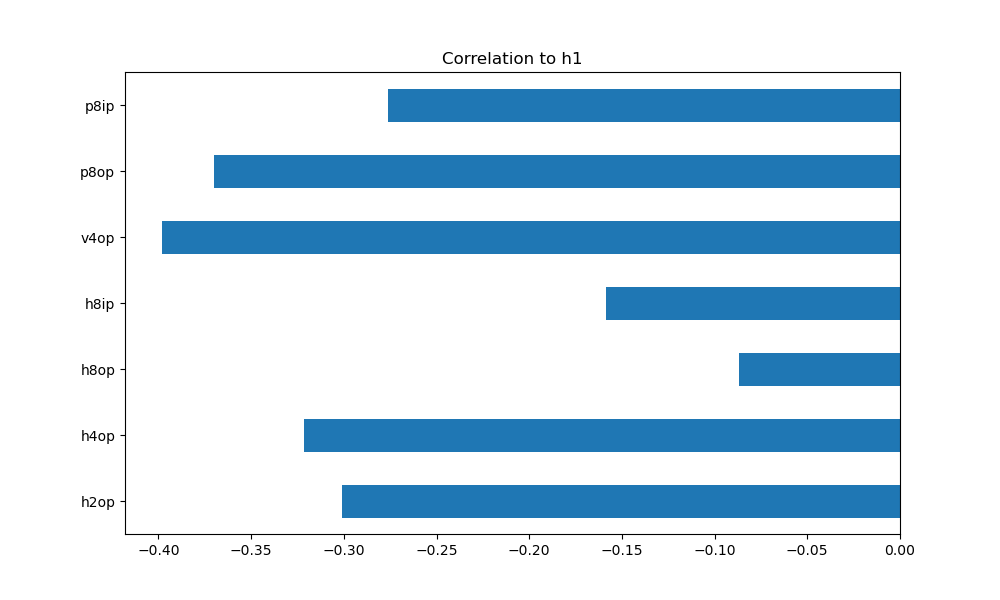

In [24]:
plt.figure()
correlation_values_h1 = Data.corr()['h1'].drop(['h1', 'logs1', 'logs2'])
correlation_values_h1.plot(kind='barh', figsize=(10, 6))
plt.title('Correlation to h1')

Text(0.5, 1.0, 'Correlation to s1')

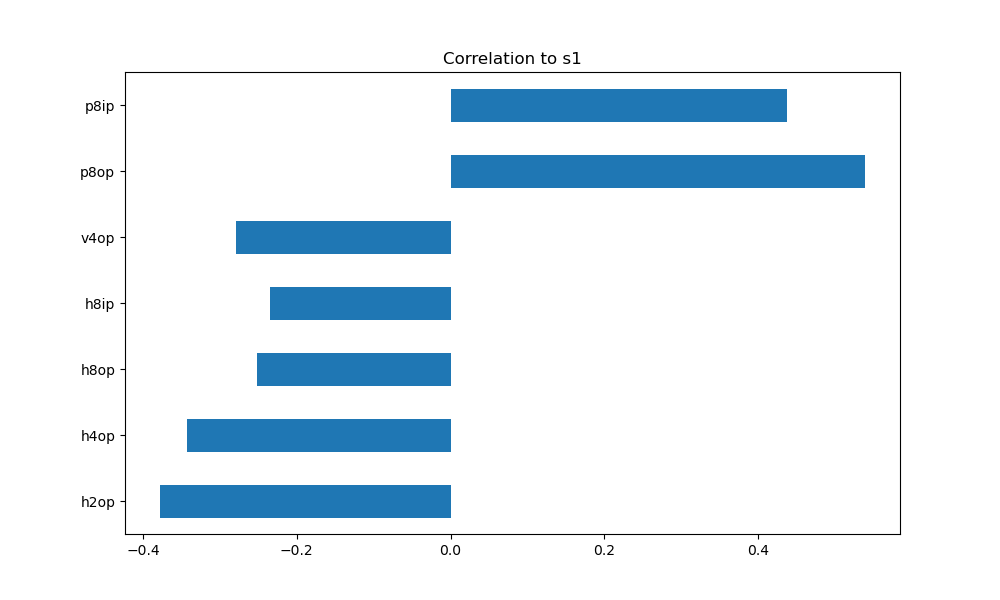

In [25]:
plt.figure()
correlation_values_h1 = Data.corr()['logs1'].drop(['h1', 'logs1', 'logs2'])
correlation_values_h1.plot(kind='barh', figsize=(10, 6))
plt.title('Correlation to s1')

Text(0.5, 1.0, 'Correlation to s2')

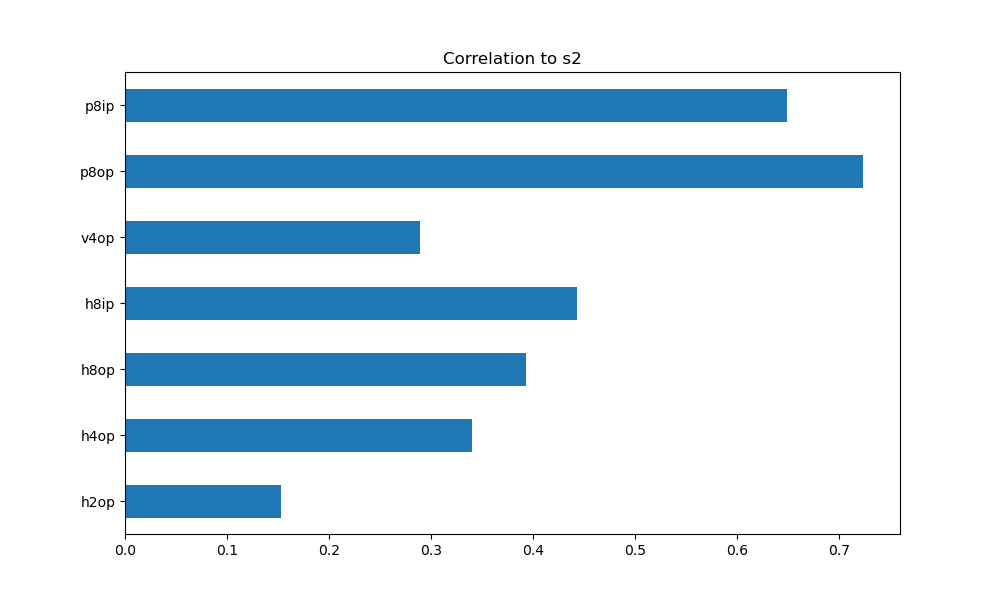

In [26]:
plt.figure()
correlation_values_h1 = Data.corr()['logs2'].drop(['h1', 'logs1', 'logs2'])
correlation_values_h1.plot(kind='barh', figsize=(10, 6))
plt.title('Correlation to s2')

<Axes: >

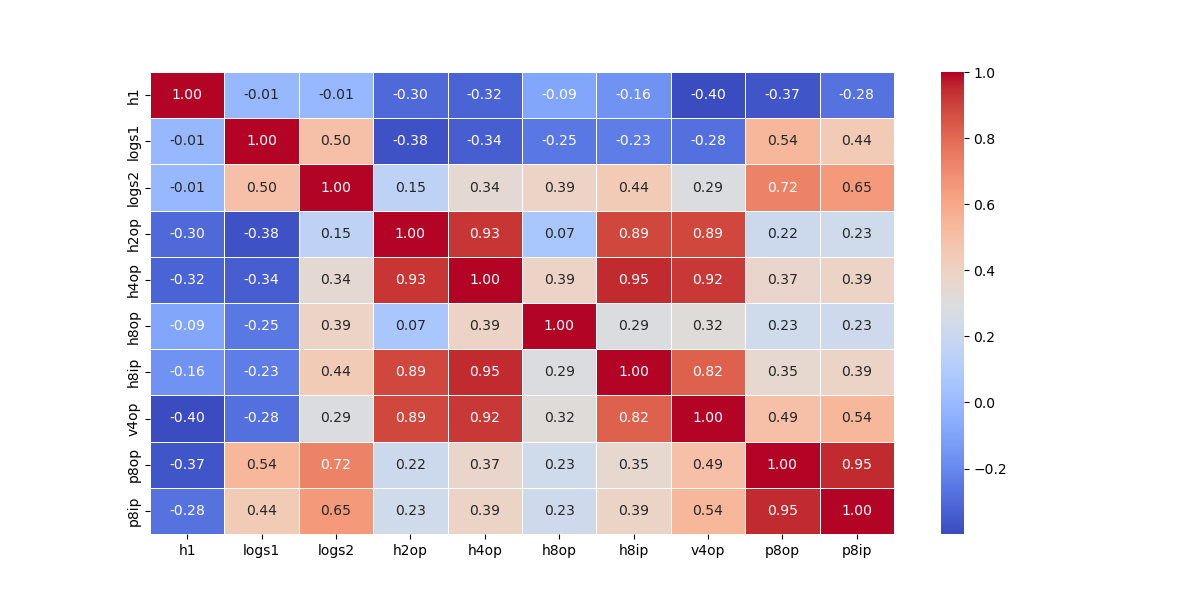

In [27]:
plt.figure(figsize=(12, 6))
correlation_matrix = Data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

In [28]:
# Standarize

scale_x = StandardScaler()
scale_y = StandardScaler()

Data_X = Data.drop(['h1', 'logs1', 'logs2'], axis=1)
Data_y = Data.drop(['h2op', 'h4op', 'h8op', 'h8ip', 'v4op',
                     'p8op', 'p8ip'], axis=1)

X = scale_x.fit_transform(Data_X)
y = scale_y.fit_transform(Data_y)
# Split data

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)

# Add noise

noise_std = 0.05
rng = np.random.RandomState(1)
y_train_noisy = y_train + rng.normal(loc=0.0, scale=noise_std, size=y_train.shape)
X_train_noisy = X_train + rng.normal(loc=0.0, scale=noise_std, size=X_train.shape)

In [29]:
# Define the model
mlp = MLPRegressor(max_iter=2000, early_stopping=True, random_state=42)

# Define the parameter grid
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50), (50, 50, 50)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'sgd'],
    'learning_rate': ['constant', 'adaptive'],
    'alpha': [0.0001, 0.001, 0.01],  # L2 regularization term
}

# Set up the grid search
grid_search = GridSearchCV(mlp, param_grid, cv=5, scoring='r2', n_jobs=20, verbose=1)

# Fit the model
grid_search.fit(X_train_noisy, y_train_noisy)

# Best parameters
# Best parameters
print("Best parameters:", grid_search.best_params_)
print("Best R² score:", grid_search.best_score_)

Fitting 5 folds for each of 120 candidates, totalling 600 fits
Best parameters: {'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (50, 50, 50), 'learning_rate': 'constant', 'solver': 'adam'}
Best R² score: 0.8644356775882317


In [30]:
test_score = grid_search.score(X_test, y_test)
print(f"{test_score:.3f}")

0.904


In [31]:
# Make predictions on the entire test set
y_pred = grid_search.predict(X_test)

# Compute metrics for each output variable separately
for i in range(y_test.shape[1]):  # Loop through each target variable
    r2 = r2_score(y_test[:, i], y_pred[:, i])
    mae = mean_absolute_error(y_test[:, i], y_pred[:, i])
    mse = mean_squared_error(y_test[:, i], y_pred[:, i])
    
    print(f"Output variable {i+1}:")
    print(f"  R² Score: {r2:.4f}")
    print(f"  Mean Absolute Error (MAE): {mae:.4f}")
    print(f"  Mean Squared Error (MSE): {mse:.4f}\n")

Output variable 1:
  R² Score: 0.7673
  Mean Absolute Error (MAE): 0.2876
  Mean Squared Error (MSE): 0.2323

Output variable 2:
  R² Score: 0.9608
  Mean Absolute Error (MAE): 0.1340
  Mean Squared Error (MSE): 0.0400

Output variable 3:
  R² Score: 0.9846
  Mean Absolute Error (MAE): 0.0726
  Mean Squared Error (MSE): 0.0154



In [32]:
n = 200

# Define a single test sample (ensure it's 2D: shape (1, n_features))
X_test_single = X_test[n].reshape(1, -1)  # Pick the first test sample

# Make prediction
y_pred_single = grid_search.predict(X_test_single)

# Print the predicted value
print("Predicted output for the single test sample:", scale_y.inverse_transform(y_pred_single))
print('True output for the test sample             ', scale_y.inverse_transform(y_test[n].reshape(1, -1)))
mse = mean_squared_error(y_test[n], y_pred_single[0])
print('mean squared error:', mse)

Predicted output for the single test sample: [[ 3.45652924 -2.56757337 -1.92169667]]
True output for the test sample              [[ 4.07346939 -2.32653061 -1.71428571]]
mean squared error: 0.10813865747708984


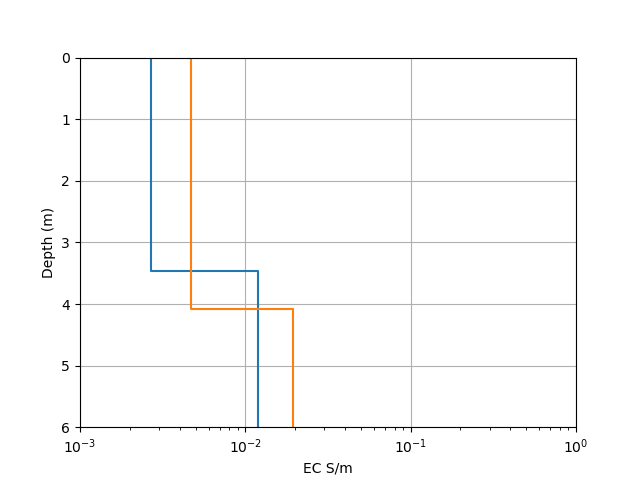

In [33]:
fig, ax = plt.subplots()

y_true_scaled = scale_y.inverse_transform(y_test[n].reshape(1, -1))
s_true = 10**y_true_scaled[0][1:]
h1_true = [y_true_scaled[0]]

y_pred_scaled = scale_y.inverse_transform(y_pred_single)
s_pred = 10**y_pred_scaled[0][1:]
h1_pred = [y_pred_scaled[0]]

drawModel1D(values=s_pred, thickness=h1_pred, ax=ax, label ='Pred' , zmax=7, xlabel='EC S/m')
drawModel1D(values=s_true, thickness=h1_true, ax=ax, label ='True' , zmax=7, xlabel='EC S/m')
ax.set_ylim([6, 0])
ax.set_xlim([1/1000, 1])
ax.set_xscale('log')

Text(0.5, 1.0, 'log s2 - r2: 0.9846')

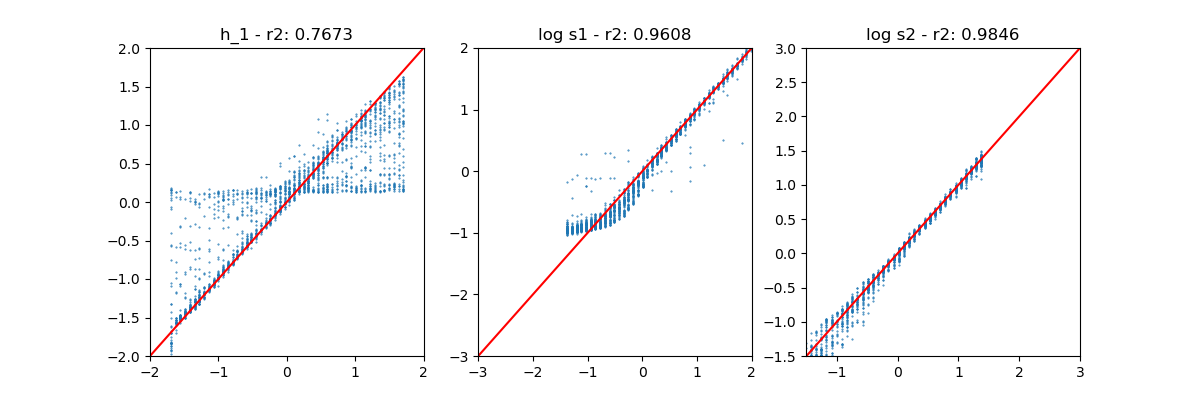

In [34]:
fig, ax = plt.subplots(1,3, figsize=(12,4))

ax[0].scatter(y_test[:,0], y_pred[:,0], s=0.2)
r2_h1 = r2_score(y_test[:, 0], y_pred[:, 0])
ax[0].plot([-2, 2], [-2, 2], 'r')
ax[1].scatter(y_test[:,1], y_pred[:,1], s=0.2)
r2_s1 = r2_score(y_test[:, 1], y_pred[:, 1])
ax[1].plot([-3,2], [-3,2], 'r')
ax[2].scatter(y_test[:,2], y_pred[:,2], s=0.2)
r2_s2 = r2_score(y_test[:, 2], y_pred[:, 2])
ax[2].plot([-1.5, 3], [-1.5, 3], 'r')

ax[0].set_xlim([-2, 2])
ax[0].set_ylim([-2, 2])

ax[1].set_xlim([-3, 2])
ax[1].set_ylim([-3, 2])

ax[2].set_xlim([-1.5, 3])
ax[2].set_ylim([-1.5, 3])

ax[0].set_title(f'h_1 - r2: {r2_h1:.4f}')
ax[1].set_title(f'log s1 - r2: {r2_s1:.4f}')
ax[2].set_title(f'log s2 - r2: {r2_s2:.4f}')